In [5]:
# Clustering tutorial in Jupyter: load dataset, scatter plot, cluster with 3 distance measures, compare with silhouette score.
# File used: /mnt/data/dataset_alimentos.xlsx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances
import os

In [23]:
# --- 1) Cargar datos ---
current_dir = os.getcwd()
file_path = os.path.join(current_dir, "dataset_alimentos.xlsx")
df = pd.read_excel(file_path)
#print("Dimensiones del dataset:", df.shape)
#print(df.head(6))
# Selección de columnas
col_x = "Calorías (kcal)"
col_y = "Grasa (g)"
data = df[[col_x, col_y]].copy()

# Asegurar tipos numéricos y eliminar NA
data[col_x] = pd.to_numeric(data[col_x], errors='coerce')
data[col_y] = pd.to_numeric(data[col_y], errors='coerce')
data = data.dropna().reset_index(drop=True)
#data.head(6)

0      254
1      440
2      113
3      318
4      253
      ... 
195    339
196    145
197    245
198    622
199    195
Name: Calorías (kcal), Length: 200, dtype: int64


In [24]:
# --- 2) Escalado ---
scaler = StandardScaler()
X = scaler.fit_transform(data[[col_x, col_y]])
escalado=pd.DataFrame(X,columns=[col_x,col_y] )
escalado.head(6)

,Calorías (kcal),Grasa (g)
0,-0.911974,1.399591
1,-0.185659,-0.943269
2,-1.462567,0.863273
3,-0.662059,0.202756
4,-0.915878,0.897146
5,0.950671,1.134255


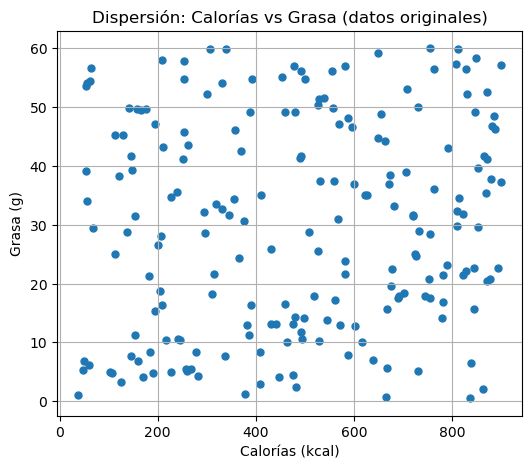

In [28]:
# --- 3) Gráfico de dispersión original ---
plt.figure(figsize=(6,5))
plt.scatter(data[col_x], data[col_y], s=25)
plt.xlabel(col_x)
plt.ylabel(col_y)
plt.title("Dispersión: Calorías vs Grasa (datos originales)")
plt.grid(True)
plt.show()

In [29]:
# --- 4) Clustering con 3 medidas Euclidiana
n_clusters = 3
results = {}

# 4.1 KMeans -> Euclidiana
km = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
labels_km = km.fit_predict(X)
results['euclid'] = labels_km
inerciaEu=km.inertia_

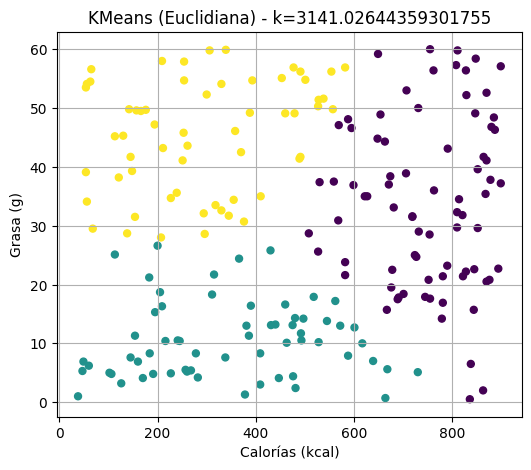

In [62]:
# --- 5) Graficar los resultados ---
def plot_clusters(data_df, col_x, col_y, labels, title):
    plt.figure(figsize=(6,5))
    plt.scatter(data_df[col_x], data_df[col_y], c=labels, s=25)
    plt.xlabel(col_x)
    plt.ylabel(col_y)
    plt.title(title)
    plt.grid(True)
    plt.show()
plot_clusters(data, col_x, col_y, labels_km, "KMeans (Euclidiana) - k=3"+str(inerciaEu))


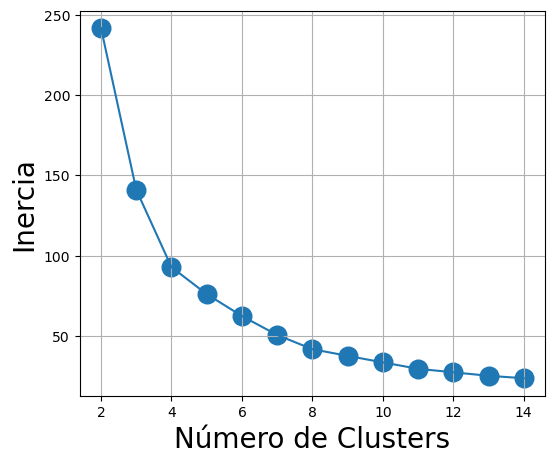

In [30]:
# --- 6) Determinar el numero optimo de clusters (Metodo del Codo)

inercias=[]
limite_clusters=15
for k in range(2, limite_clusters):
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit(X)                    # Entrena el modelo
    inercias.append(kmeans.inertia_) # Guarda la inercia

plt.figure(figsize=(6,5), dpi=100)
plt.scatter(range(2,limite_clusters), inercias, marker="o", s=180)
plt.plot(range(2,limite_clusters), inercias)     # para ver la curva
plt.xlabel("Número de Clusters", fontsize=20)
plt.ylabel("Inercia", fontsize=20)
plt.grid(True)
plt.show()

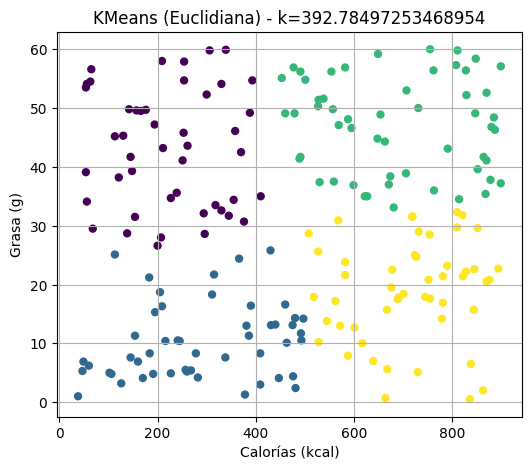

In [75]:
# --- 7) Repetir clusterin con el numero optimo de clusters
n_clusters = 4
results = {}

# 4.1 KMeans -> Euclidiana
km = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
labels_km = km.fit_predict(X)
results['euclid'] = labels_km
inerciaEu=km.inertia_

def plot_clusters(data_df, col_x, col_y, labels, title):
    plt.figure(figsize=(6,5))
    plt.scatter(data_df[col_x], data_df[col_y], c=labels, s=25)
    plt.xlabel(col_x)
    plt.ylabel(col_y)
    plt.title(title)
    plt.grid(True)
    plt.show()
plot_clusters(data, col_x, col_y, labels_km, "KMeans (Euclidiana) - k=3"+str(inerciaEu))

In [32]:
# --- 8) Guardar resultado con etiquetas ---
df_out = data.copy()
df_out['cluster'] = labels_km
out_path = os.path.join(current_dir, "dataset_alimentos_resultado_etiquetas.xlsx")
df_out.to_excel(out_path, index=False)
print("Archivo guardado en:", out_path)

Archivo guardado en: /home/jovyan/work/ejemplos jupyterlab/Tecnicas no supervisadas/dataset_alimentos_resultado_etiquetas.xlsx
